# Representing and Manipulating Data Assignment
## Importing libraries which are requried

## 1. Business Understanding

What we’re aiming for: We want to get a good understanding of how JC Penney customers feel about the products and how those products actually perform based on the review data.

What we’re looking at: By reviewing the ratings, price points, and frequency of reviews, we want to find trends that can help steer the business in a positive direction in terms of customer satisfaction.

What we’re looking for:
- What types of products have the highest and lowest ratings?
- What types of products have the most reviews?
- Do products with a higher price point have a higher rating?
- What does the rating distribution say about overall customer satisfaction?
- What products need work based on the reviews?

## 2. Data Understanding

The data is scattered across several files, and everything is linked by who has written what and what the products are.

Files used in this analysis:

- products.csv, where the fundamental data about the products is stored, including the name, category, price, and a small description.
- reviews.csv, where the opinions from the customers are stored, along with the scores they provided for each review.
- users.csv, where information about the users is available.
- jcpenney_products.json, where additional information is available for the products.
- jcpenney_reviewers.json, where information about the users who reviewed the products is available in JSON format.

Explanation of how these pieces fit together:
- Uniq_id is the link between the products and the reviews for each product.
- Username is the link between users and the reviews written by them.

What we did initially:
- We examined the data structures.
- We examined if there were any missing values.
- We examined the data types for each column.
- We generated descriptive statistics.

Importing Libraries

In [53]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt


In [54]:
import os
os.getcwd() #to get our current working directory we use getcwd() function

'c:\\Users\\aksha\\OneDrive\\Desktop\\D2_Assignment'

### importing CSV files

In [55]:
products = pd.read_csv(r"JCPenneyFiles\JCPenneyFiles\products.csv") #to get/read products.csv file into out code
reviews = pd.read_csv(r"JCPenneyFiles\JCPenneyFiles\reviews.csv") #to get/read reviews.csv file into out code
users = pd.read_csv(r"JCPenneyFiles\JCPenneyFiles\users.csv") #to get/read users.csv file into out code

### Getting information about CSV Files

In [56]:
print("Products dataset shape:", products.shape)

Products dataset shape: (7982, 6)


In [57]:
print("Reviews dataset shape:", reviews.shape)


Reviews dataset shape: (39063, 4)


In [58]:
print("Users dataset shape:", users.shape)

Users dataset shape: (5000, 3)


In [59]:
products_df = pd.read_json(
    r"JCPenneyFiles\JCPenneyFiles\jcpenney_products.json",
    lines=True
)
reviewers_df = pd.read_json(
    r"JCPenneyFiles\JCPenneyFiles\jcpenney_reviewers.json",
    lines=True
)
products_df.head() #to get first 5 rows of products csv file

,uniq_id,sku,name_title,description,list_price,sale_price,category,category_tree,average_product_rating,product_url,product_image_urls,brand,total_number_reviews,Reviews,Bought With
0,b6c0b6bea69c722939585baeac73c13d,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'fsdv4141', 'Review': 'You never hav...","[898e42fe937a33e8ce5e900ca7a4d924, 8c02c262567..."
1,93e5272c51d8cce02597e3ce67b7ad0a,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,alfred dunner,jcpenney|women|alfred dunner,3.000,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'tpcu2211', 'Review': 'You never hav...","[bc9ab3406dcaa84a123b9da862e6367d, 18eb69e8fc2..."
2,013e320f2f2ec0cf5b3ff5418d688528,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,2.625,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'pcfg3234', 'Review': 'You never hav...","[3ce70f519a9cfdd85cdbdecd358e5347, b0295c96d2b..."
3,505e6633d81f2cb7400c0cfa0394c427,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,3.500,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'ngrq4411', 'Review': 'You never hav...","[efcd811edccbeb5e67eaa8ef0d991f7c, 7b2cc00171e..."
4,d969a8542122e1331e304b09f81a83f6,pp5006380337,Alfred Dunner® Essential Pull On Capri Pant,You'll return to our Alfred Dunner pull-on cap...,41.09,24.16,view all,jcpenney|women|view all,3.125,http://www.jcpenney.com/alfred-dunner-essentia...,http://s7d9.scene7.com/is/image/JCPenney/DP122...,Alfred Dunner,8,"[{'User': 'nbmi2334', 'Review': 'You never hav...","[0ca5ad2a218f59eb83eec1e248a0782d, 9869fc8da14..."


In [60]:
reviewers_df.head() #to get first 5 rows of reviewers

,Username,DOB,State,Reviewed
0,bkpn1412,31.07.1983,Oregon,[cea76118f6a9110a893de2b7654319c0]
1,gqjs4414,27.07.1998,Massachusetts,[fa04fe6c0dd5189f54fe600838da43d3]
2,eehe1434,08.08.1950,Idaho,[]
3,hkxj1334,03.08.1969,Florida,"[f129b1803f447c2b1ce43508fb822810, 3b0c9bc0be6..."
4,jjbd1412,26.07.2001,Georgia,[]


In [61]:
users.head() #to get first 5 rows of users file

,Username,DOB,State
0,bkpn1412,31.07.1983,Oregon
1,gqjs4414,27.07.1998,Massachusetts
2,eehe1434,08.08.1950,Idaho
3,hkxj1334,03.08.1969,Florida
4,jjbd1412,26.07.2001,Georgia


In [62]:
products.info() #to get structure of products file

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7982 entries, 0 to 7981
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Uniq_id      7982 non-null   object 
 1   SKU          7915 non-null   object 
 2   Name         7982 non-null   object 
 3   Description  7439 non-null   object 
 4   Price        5816 non-null   float64
 5   Av_Score     7982 non-null   float64
dtypes: float64(2), object(4)
memory usage: 374.3+ KB


In [63]:
reviews.info() #to get structure of reviews csv file

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39063 entries, 0 to 39062
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Uniq_id   39063 non-null  object
 1   Username  39063 non-null  object
 2   Score     39063 non-null  int64 
 3   Review    39063 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB


In [64]:
users.info() #to get structure of users csv file

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Username  5000 non-null   object
 1   DOB       5000 non-null   object
 2   State     5000 non-null   object
dtypes: object(3)
memory usage: 117.3+ KB


In [65]:
products.describe() #to get description of products file

,Price,Av_Score
count,5816.000000,7982.000000
mean,144.776618,2.988683
std,499.223719,0.911673
min,-65.270000,1.000000
25%,40.700000,2.500000
50%,58.010000,3.000000
75%,87.020000,3.500000
max,17122.170000,5.000000


In [66]:
reviews.describe() #to get description of reviews file

,Score
count,39063.000000
mean,1.487648
std,1.400332
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,5.000000


In [67]:
users.describe() #to get description of users file

,Username,DOB,State
count,5000,5000,5000
unique,4999,52,57
top,dqft3311,07.08.1953,Massachusetts
freq,2,112,107


### Checking Missing Values

In [68]:
products.isnull().sum() #checking how many are missing values in products csv file

Uniq_id           0
SKU              67
Name              0
Description     543
Price          2166
Av_Score          0
dtype: int64

## 3. Data Preparation

### Filling the Missing values

The missing information in the data was handled in a manner that ensures proper analysis. This was done by setting the information in the SKU column to "Unknown," the information in the Description column to "No Description," and the missing information in the Price column to the average price.

In [69]:
# products = products.dropna()
# or we can also fill the missing values with mean imputation like
products["SKU"] = products["SKU"].fillna("Unknown") #filling missing values in SKU column with "Unknown"
products["Description"] = products["Description"].fillna("No Description") #filling missing values in Description column with "No Description"
products["Price"] = products["Price"].fillna(products["Price"].mean()) #filling missing values in Price column with mean

In [70]:
products.isnull().sum() #veryfing that there are no missing values in products csv file

Uniq_id        0
SKU            0
Name           0
Description    0
Price          0
Av_Score       0
dtype: int64

In [71]:
reviews.isnull().sum() #checking how many are missing values in reviews csv file

Uniq_id     0
Username    0
Score       0
Review      0
dtype: int64

In [72]:
users.isnull().sum() #checking how many are missing values in users csv file

Username    0
DOB         0
State       0
dtype: int64

In [73]:
products["Price"].describe() #this is the description after filling the missing values from products csv file

count     7982.000000
mean       144.776618
std        426.129318
min        -65.270000
25%         47.300000
50%         75.640000
75%        144.776618
max      17122.170000
Name: Price, dtype: float64

## Merging Tables

The tables are joined to combine related data from different sources. One table has product data, while the other has customer ratings and feedback data. By joining these two tables using a common key, we are able to link product data with customer ratings data under the common column of Uniq_id.

In [74]:
merged = pd.merge(products, reviews, on="Uniq_id")
merged.groupby("Name")["Score"].mean() #to get the average rating for each product

Name
1 CT. Certified Diamond Solitaire Ring                           2.333333
1 CT. T.W. Certified Diamond 14K White Gold Bridal Ring Set      5.000000
1 CT. T.W. Certified Diamond 14K White Gold Princess-Cut Band    1.000000
1 CT. T.W. Certified Diamond 14K Yellow Gold Bridal Ring Set     1.000000
1 CT. T.W. Diamond 10K White Gold Cluster Ring                   0.000000
                                                                   ...   
¼ CT. T.W. White & Color-Enhanced Black Diamond Weave Ring       2.000000
½ CT. Princess Certified Diamond Solitaire Ring                  1.000000
½ CT. T.W. Diamond 10K Yellow Gold Contoured Anniversary Band    0.750000
½ CT. T.W. Diamond Bridal Set                                    0.000000
⅓ CT. T.W. Diamond 3-Stone Promise Ring                          1.000000
Name: Score, Length: 6001, dtype: float64

In [75]:
users_reviews = pd.merge(users, reviews, on="Username")
users.head() #to get first 5 rows of users csv file

,Username,DOB,State
0,bkpn1412,31.07.1983,Oregon
1,gqjs4414,27.07.1998,Massachusetts
2,eehe1434,08.08.1950,Idaho
3,hkxj1334,03.08.1969,Florida
4,jjbd1412,26.07.2001,Georgia


## 4. Insight Analysis

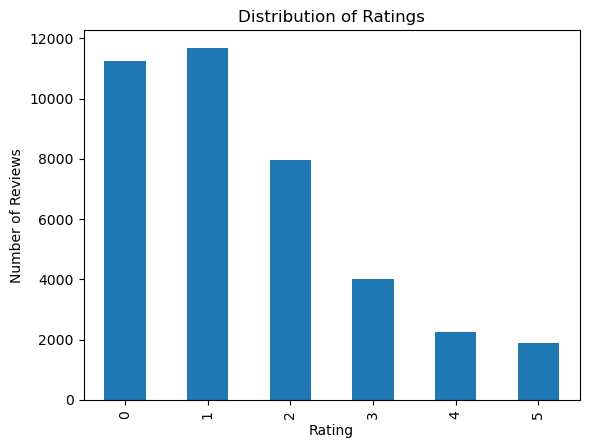

In [76]:
merged["Score"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Ratings")
plt.show()

In [77]:
rating_summary = merged.groupby("Score")["Name"].nunique().reset_index() #it gives how many unique products received each rating at least once
rating_summary.columns = ["Rating", "Number_of_Products"]
rating_summary

,Rating,Number_of_Products
0,0,4146
1,1,4243
2,2,3612
3,3,2388
4,4,1637
5,5,1437


In [78]:
merged.sort_values(by="Price", ascending=False)[["Name", "Price"]].head()

,Name,Price
28396,1½ CT. Round Certified Diamond Solitaire 14K Y...,17122.17
9317,Mens 1/2 CT. T.W. Diamond & Onyx 14K Gold Link...,13699.64
24634,1 CT. T.W. Diamond 14K White Gold Engagement Ring,9064.69
21335,Harmony Eternally in Love 3 CT. T.W. Certified...,8661.79
21329,Harmony Eternally in Love 3 CT. T.W. Certified...,8661.79


In [79]:
reviews["Uniq_id"].value_counts().head() #to get the top 5 products with most number of reviews

Uniq_id
7376425db74399716d23f1cc0c59684c    23
6c40fb8c09f9b94ef12003656c808cf1    23
2ce274384d293748bbf8bdebbc0aa145    23
867b08603fa032314919f0d7b5d47ad6    22
0db3122709238f7154dffa1baeedee3f    21
Name: count, dtype: int64

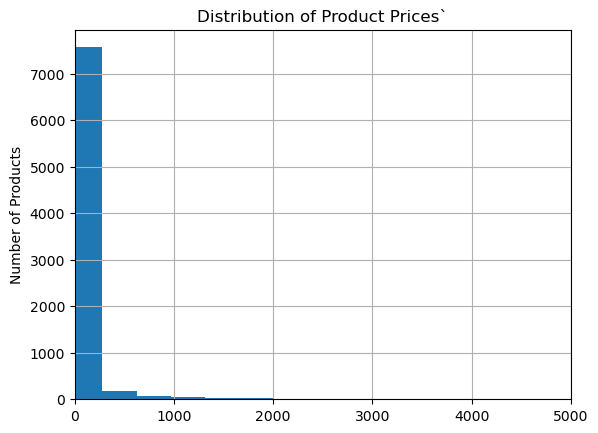

In [80]:
products["Price"].hist(bins=50)
plt.xlim(0, 5000)  
plt.ylabel("Number of Products")
plt.title("Distribution of Product Prices`")
plt.show()


It shows how prices are distributed for the given set of products. The histogram shows how many items are within a certain range. The plt.xlim(0, 5000) is used to focus on a certain range of prices, from 0 to 5000. This range is chosen because prices are usually not extremely high. By selecting this range, we are essentially ignoring those high prices and only looking at the majority of prices. This is useful to understand how prices are distributed for the given set of products.

In [81]:
full_dataa = pd.merge(users_reviews, products, on="Uniq_id") #merging users and reviews data with products data to get a complete analysis
full_dataa.head() #to get first 5 rows of the merged data

,Username,DOB,State,Uniq_id,Score,Review,SKU,Name,Description,Price,Av_Score
0,bkpn1412,31.07.1983,Oregon,2565bf02ec05a59cd1fd78955dda108d,0,Love this heated mattress pad! Ordered the que...,pp5003160034,Biddeford® Heated Mattress Pad,Turn down the thermostat and turn up this comf...,144.776618,2.500000
1,bkpn1412,31.07.1983,Oregon,e09b42d19cd350f9762f92d59ecf88ba,2,"I am 511 and a size 6, with a very straight fi...",pp5006720496,Worthington® Wide Waistband Cropped Pants - Tall,Enjoy the comfort of a modern fit and wide wai...,48.340000,2.428571
2,bkpn1412,31.07.1983,Oregon,cea76118f6a9110a893de2b7654319c0,0,I like the jacket accept it is thin not and th...,pp5005290257,Silverwear™ Short-Sleeve Hooded Eyelet Jacket ...,Our short-sleeve French terry knit jacket is t...,52.030000,3.000000
3,bkpn1412,31.07.1983,Oregon,bc177e6724df06c676fd526e6d32461d,2,"Soft, comfortable, and it fits nice. Whats not...",pp5006950440,Made for Life™ Mesh Print Tank Top or Shorts,No Description,144.776618,3.375000
4,bkpn1412,31.07.1983,Oregon,a0d0f5f772021d6320048dc7b61fb551,5,I bought the quick dri bath rug in the size 21...,pp5003380128,JCPenney Home™ Ultra Soft Quick-Dri Bath Rug C...,Step into ultra soft luxury when you add these...,144.776618,3.000000


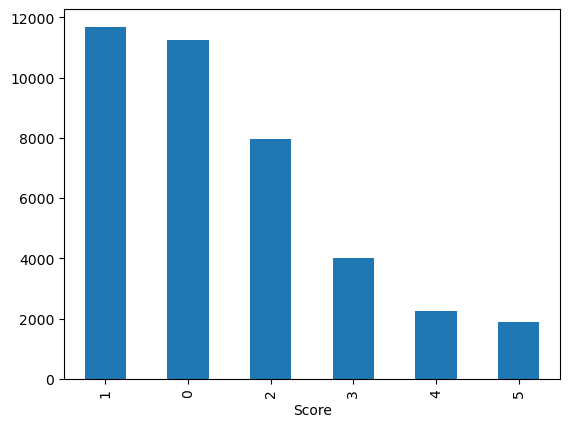

In [82]:
reviews["Score"].value_counts().plot(kind="bar")
plt.show()

The bar chart illustrates how users in the data set have allocated their rating scores. From the bar chart, it is clear that a score of 1 is the most frequent, with a score of 0 following closely behind. This implies that these two scores appear more often in the data set compared to other scores. On the other hand, scores 2 and 3 appear to a lesser degree, while scores 4 and 5 appear least in the data set.

In [83]:
print("Median Product Price:", products["Price"].median())

Median Product Price: 75.64


In [84]:
# Creating the price the price labels to specify the catogory
price_ranges = pd.cut(products["Price"],
                      bins=[0,50,100,200,400,600,800,1000,5000],
                      labels=["1-50","51-100","101-200","201-400","401-600","601-800","801-1000","1000+"])
price_counts = price_ranges.value_counts().sort_index() # it gives the number of products within each price range

print(price_counts)

Price
1-50        2223
51-100      2361
101-200     2791
201-400      245
401-600       79
601-800       55
801-1000      30
1000+        144
Name: count, dtype: int64


The median price was used to assess the price level in the data set. Unlike the average price, the median price does not fluctuate with high or low prices. Therefore, it is a more consistent measure of central tendency. Products within ±10% of the median were used to identify items that are within the normal range. These items are not likely to be impacted by high or low prices and are used to demonstrate how prices are set by the retailer.

In [85]:
top_rated_products = merged.groupby("Name")["Score"].mean().sort_values(ascending=False).head(10)
print(top_rated_products)

Name
Fabric Possibilities Track-Arm 4-pc. Left-Arm Loveseat/Chaise Sectional    5.0
Home Expressions™ Rosetti Euro Sham                                        5.0
T-Fal® Family Pro Deep Fryer                                               5.0
Collection by Michael Strahan Striped Black Suit Separates - Big & Tall    5.0
Collection by Michael Strahan Reversible Textured-Buckle Belt              5.0
St. Johns Bay® Long-Sleeve Essential Crewneck T-Shirt- Petite              5.0
ZCO Shape Bootcut Jeans - Plus                                             5.0
1 CT. T.W. Certified Diamond 14K White Gold Bridal Ring Set                5.0
Lugz® Empire Hi Mens Water-Resistant Hiking Boots                          5.0
Classic Treasures™ Lab-Created Ruby and Diamond-Accent Drop Earrings       5.0
Name: Score, dtype: float64


## Conclusion
This study delved into the JCPenney dataset using Python and various data processing tools such as Pandas and Matplotlib. After processing the data and handling the missing values and the union of the various datasets, the analysis could be conducted. The main idea of the analysis is that most of the items were within the mid-range price category. There were also only a few items that were priced extremely high.

With regard to the ratings of the items, the analysis revealed that the most common ratings were 1 and 0. On the other hand, ratings of 4 and 5 were less common. This could be an indication of the quality of the products and the customer experience. The analysis also revealed which products were receiving the most reviews. This could be an indication of the exposure of the products. With the analysis of the data, various businesses could improve their sales by improving the quality of the products that were rated low and promoting the ones that were rated high.